# Telco Müşteri Kaybı (Churn) — Analiz & Tahmin
# Telco Customer Churn — Analysis & Prediction

**TR —** Bu projede bir telekom şirketinin hangi müşterilerinin aboneliğini iptal
edeceğini (churn) tahmin etmeye ve *nedenlerini* anlamaya çalıştım. Amacım sadece bir
model kurmak değil; hangi müşterinin risk altında olduğunu önceden görüp elde tutma
(retention) aksiyonlarını doğru kişilere yöneltebilmekti.

**EN —** In this project I set out to predict which telecom customers will churn (cancel
their subscription) and to understand *why*. My goal was not just to fit a model, but to
flag at-risk customers early so retention actions can be targeted where they matter.

---
**TR — İzlediğim yol:** temizlik → keşifçi analiz (EDA) → feature engineering →
model kurma (3 model) → Optuna ile hiperparametre optimizasyonu → threshold ayarı →
SHAP ile açıklanabilirlik → iş önerileri.

**EN — My workflow:** cleaning → EDA → feature engineering → modeling (3 models) →
hyperparameter tuning with Optuna → threshold tuning → SHAP explainability → business
recommendations.

> **TR —** Tekrar kullanılabilir kodu `src/` altına koydum; bu notebook hikâyeyi anlatıyor.
> **EN —** I keep the reusable logic in `src/`; this notebook tells the story.

## 0. Kurulum / Setup
**TR —** Notebook'u hem yerelde hem de Colab'da çalıştırabilmek için küçük bir kurulum
hücresi yazdım. Colab'da sadece notebook açıksa repoyu klonluyor.
**EN —** I wrote a small setup cell so the notebook runs both locally and on Colab. On a
fresh Colab it clones the repo.

In [ ]:
# TR: Colab'da src yoksa repoyu klonla; yereldeyse ../src'i yola ekle
# EN: on Colab clone the repo if src is missing; locally add ../src to the path
import sys, os
IN_COLAB = "google.colab" in sys.modules
if not os.path.exists("src") and not os.path.exists("../src"):
    # TR: taze Colab -> repoyu çek (kendi kullanıcı adını yaz)
    # EN: fresh Colab -> clone the repo (put your own GitHub username)
    !git clone -q https://github.com/derinteke/telco-churn-analysis.git
    %cd telco-churn-analysis
sys.path.append("." if os.path.exists("src") else "..")

if IN_COLAB:
    !pip install -q optuna xgboost lightgbm shap

In [2]:
# TR: Kullandığım kütüphaneler / EN: the libraries I use
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

from src.data import load_clean
from src.features import engineer, split_X_y
from src.model import build_models
from src.evaluate import print_report
from src import config

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RS = config.RANDOM_STATE

## 1. Veriyi yükle & temizle / Load & clean
**TR —** `load_clean()` fonksiyonuma bu setin bilinen sorunlarını çözdürdüm: `TotalCharges`
metin olarak gelmiş ve yeni müşterilerde (tenure 0) boş; onu sayıya çevirip dolduruyorum.
`SeniorCitizen` 0/1 -> okunur kategori, hedef değişken 0/1'e mapleniyor.
**EN —** My `load_clean()` fixes the known quirks: `TotalCharges` comes as text and is blank
for brand-new customers (tenure 0), so I coerce and fill it. `SeniorCitizen` 0/1 -> readable
category, and the target is mapped to 0/1.

In [3]:
df = load_clean()
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [4]:
# TR: Churn oranı ve sınıf dengesi / EN: churn rate and class balance
churn_rate = df[config.TARGET].mean()
print(f"Churn rate / Churn orani: {churn_rate:.1%}")
df[config.TARGET].value_counts()

Churn rate / Churn orani: 26.5%


Churn
0    5174
1    1869
Name: count, dtype: int64

**TR —** Müşterilerin yalnızca ~%27'si churn ediyor; yani **dengesiz** bir problem. Bu
yüzden accuracy'e güvenmiyorum ("kimse churn etmez" diyen model bile %73 alır). Ben
**ROC-AUC, recall ve F1**'e bakıyorum.

**EN —** Only ~27% of customers churn, so this is an **imbalanced** problem. I don't trust
plain accuracy (a "nobody churns" model already scores ~73%). I optimise for **ROC-AUC,
recall and F1** instead.

## 2. Keşifçi analiz / EDA
**TR —** Önce hangi değişkenlerin churn ile ilişkili olduğuna baktım.
**EN —** First I looked at which variables relate to churn.

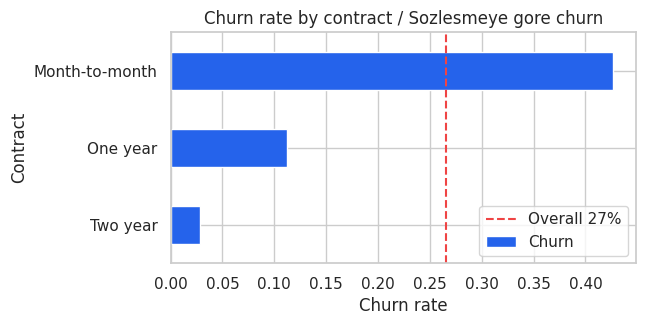

In [5]:
# TR: Sözleşme tipine göre churn oranı / EN: churn rate by contract type
rate = df.groupby("Contract")[config.TARGET].mean().sort_values()
rate.plot.barh(color="#2563eb", figsize=(6,3))
plt.axvline(churn_rate, color="#ef4444", ls="--", label=f"Overall {churn_rate:.0%}")
plt.title("Churn rate by contract / Sozlesmeye gore churn"); plt.xlabel("Churn rate")
plt.legend(); plt.show()

**TR —** En çarpıcı bulgum: aydan aya sözleşmeliler ~%43 churn ederken, 2 yıllıklar ~%3.
Sözleşme süresi tek başına en güçlü sinyal.
**EN —** My most striking finding: month-to-month customers churn at ~43% vs ~3% for
two-year contracts. Contract length alone is the strongest signal.

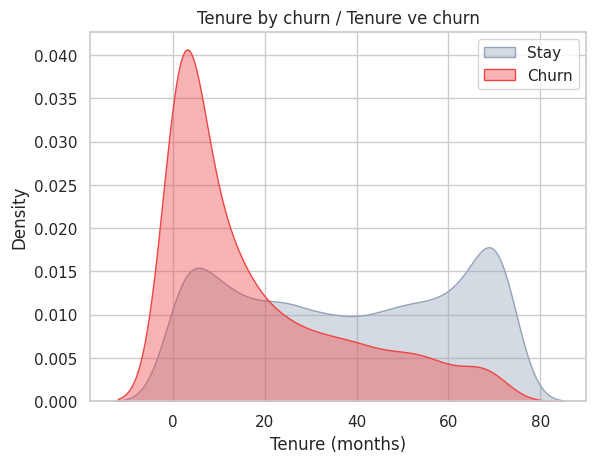

In [6]:
# TR: Tenure dagilimi (churn eden vs kalan) / EN: tenure distribution (churn vs stay)
for v,l,c in [(0,"Stay","#94a3b8"),(1,"Churn","#ef4444")]:
    sns.kdeplot(df[df[config.TARGET]==v]["tenure"], fill=True, alpha=.4, label=l, color=c)
plt.title("Tenure by churn / Tenure ve churn"); plt.xlabel("Tenure (months)")
plt.legend(); plt.show()

**TR —** Churn ilk aylarda yoğunlaşıyor. Erken dönemi atlatan müşteri büyük ölçüde
kalıyor — yani onboarding kritik.
**EN —** Churn concentrates in the first months. Customers who survive the early period
tend to stay — so onboarding is critical.

## 3. Feature Engineering
**TR —** Modele yardımcı olsun diye birkaç yeni değişken türettim (hepsini
`src/features.py -> engineer()` içine koydum): kaç ek servisi olduğu, tenure grubu,
tenure başına harcama, internet olup olmadığı ve aylık/toplam ücret oranı. Sezgim şuydu:
az servisi olan ve yeni müşteriler daha "gevşek" bağlı, dolayısıyla daha riskli.

**EN —** I engineered a few features (all inside `src/features.py -> engineer()`): number of
services, tenure band, spend-per-tenure, whether they have internet, and a monthly/total
ratio. My intuition: customers with few services and short tenure are more loosely attached,
hence riskier.

In [7]:
df_fe = engineer(df)
new_cols = ["num_services","tenure_group","charge_per_tenure","has_internet","monthly_to_total_ratio"]
df_fe[new_cols].head()

,num_services,tenure_group,charge_per_tenure,has_internet,monthly_to_total_ratio
0,1,0-1yr,14.925000,1,0.967585
1,3,2-4yr,53.985714,1,0.030124
2,3,0-1yr,36.050000,1,0.493358
3,3,2-4yr,40.016304,1,0.022967
4,1,0-1yr,50.550000,1,0.463151


## 4. İlk modeller / Baseline models
**TR —** Veriyi stratified %80/20 böldüm. Preprocessing'i (ölçekleme + one-hot) her modelin
`Pipeline`'ının **içine** koydum; böylece veri sızıntısı (leakage) olmuyor ve kaydettiğim
model ham veriyi kabul edebiliyor. Üç model deniyorum: yorumlanabilir bir Logistic Regression
temeli + iki gradient boosting (LightGBM, XGBoost).

**EN —** I split the data stratified 80/20. I put preprocessing (scaling + one-hot) **inside**
each model's `Pipeline`, so there is no leakage and the saved model accepts raw input. I try
three models: an interpretable Logistic Regression baseline + two gradient boosters
(LightGBM, XGBoost).

In [8]:
X, y = split_X_y(df_fe)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=config.TEST_SIZE, stratify=y, random_state=RS)

models = build_models()
fitted, results = {}, {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:,1]
    results[name] = print_report(name, y_test, pipe.predict(X_test), proba)
    fitted[name] = pipe


=== Logistic Regression ===
ROC-AUC : 0.846
F1      : 0.614
Precision: 0.505
Recall  : 0.783
              precision    recall  f1-score   support

           0      0.902     0.723     0.803      1035
           1      0.505     0.783     0.614       374

    accuracy                          0.739      1409
   macro avg      0.704     0.753     0.708      1409
weighted avg      0.797     0.739     0.753      1409




=== LightGBM ===
ROC-AUC : 0.848
F1      : 0.628
Precision: 0.515
Recall  : 0.805
              precision    recall  f1-score   support

           0      0.912     0.727     0.809      1035
           1      0.515     0.805     0.628       374

    accuracy                          0.747      1409
   macro avg      0.713     0.766     0.718      1409
weighted avg      0.806     0.747     0.761      1409




=== XGBoost ===
ROC-AUC : 0.850
F1      : 0.625
Precision: 0.515
Recall  : 0.797
              precision    recall  f1-score   support

           0      0.908     0.729     0.809      1035
           1      0.515     0.797     0.625       374

    accuracy                          0.747      1409
   macro avg      0.712     0.763     0.717      1409
weighted avg      0.804     0.747     0.760      1409



In [9]:
# TR: Modelleri tek tabloda karsilastir / EN: compare models in one table
pd.DataFrame(results).T.round(3).sort_values("roc_auc", ascending=False)

,roc_auc,f1,precision,recall
XGBoost,0.850,0.625,0.515,0.797
LightGBM,0.848,0.628,0.515,0.805
Logistic Regression,0.846,0.614,0.505,0.783


## 5. Hiperparametre optimizasyonu / Hyperparameter tuning (Optuna)
**TR —** Model kalitesini artırmak için Optuna ile hiperparametre araması yaptım. Aşağıda
gösterim amaçlı kısa bir arama (20 deneme) var; **tam arama** `src/tune.py` içinde ve
kazanan parametreleri `config.py`'ye kaydettim. Not: burada CV kullanıyorum, çünkü tek bir
train/test bölmesine göre parametre seçmek yanıltıcı olabilir.

**EN —** To improve the model I ran a hyperparameter search with Optuna. Below is a short
demo search (20 trials); the **full search** lives in `src/tune.py` and I saved the winning
params into `config.py`. Note I use CV here, because tuning against a single split is
misleading.

In [10]:
import optuna
from xgboost import XGBClassifier
from src.features import build_preprocessor
from sklearn.pipeline import Pipeline
optuna.logging.set_verbosity(optuna.logging.WARNING)

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RS)

def objective(trial):
    # TR: XGBoost icin arama uzayi / EN: search space for XGBoost
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 200, 900),
        learning_rate=trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        max_depth=trial.suggest_int("max_depth", 3, 9),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 10),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
    )
    clf = XGBClassifier(scale_pos_weight=config.SCALE_POS_WEIGHT, random_state=RS,
                        eval_metric="logloss", tree_method="hist", **params)
    pipe = Pipeline([("prep", build_preprocessor(scale=False)), ("clf", clf)])
    return cross_val_score(pipe, X, y, cv=CV, scoring="roc_auc", n_jobs=-1).mean()

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RS))
study.optimize(objective, n_trials=20, show_progress_bar=False)  # TR: hizli demo / EN: quick demo
print(f"Demo arama en iyi CV ROC-AUC / demo best: {study.best_value:.4f}")

Demo arama en iyi CV ROC-AUC / demo best: 0.8483


**TR —** Deneylerimden çıkan dürüst sonuç: bu veri setinin tavanı ~0.85 civarı. Kapsamlı
aramamın (LightGBM/XGBoost/CatBoost, 40-150 deneme) özeti:

**EN —** The honest result from my experiments: this dataset tops out around ~0.85. Summary
of my full search (LightGBM/XGBoost/CatBoost, 40-150 trials):

| Model / Yöntem | CV ROC-AUC | Not / Note |
|---|---|---|
| LightGBM (Optuna) | 0.848 | |
| **XGBoost (Optuna)** | **0.849** | En iyi / best |
| CatBoost (Optuna) | 0.849 | Başabaş / tied |
| Ensemble (soft vote) | 0.849 | Tek modeli geçmedi / no gain |
| SMOTE (vs scale_pos_weight) | 0.835 | **Daha kötü / worse** |

**TR —** Öğrendiğim şey: en büyük kaldıraç tuning'di, model seçimi neredeyse fark etmedi ve
SMOTE burada zarar verdi. Bu yüzden final modeli olarak tuned **XGBoost**'u seçtim.
**EN —** What I learned: tuning was the biggest lever, model choice barely mattered, and
SMOTE hurt here. So I picked the tuned **XGBoost** as my final model.

## 6. Final model + eşik ayarı / Final model + threshold tuning
**TR —** `config.py`'deki tuned XGBoost parametrelerini kullanıyorum. Varsayılan 0.50 eşiği
recall'ü öne çıkarıyor (churn edenleri yakalamak); F1'i maksimize eden eşiği de hesaplayıp
karşılaştırdım. Kampanya bütçesine göre bu eşik iş tarafında ayarlanabilir.

**EN —** I use the tuned XGBoost params from `config.py`. The default 0.50 threshold favours
recall (catching churners); I also compute the F1-maximising threshold and compare. In
practice this threshold can be set by the business depending on campaign budget.

In [11]:
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             precision_score, recall_score, precision_recall_curve)
best = fitted["XGBoost"]
proba = best.predict_proba(X_test)[:,1]
print(f"Holdout ROC-AUC: {roc_auc_score(y_test, proba):.4f}")
print(f"Holdout PR-AUC : {average_precision_score(y_test, proba):.4f}\n")

prec, rec, thr = precision_recall_curve(y_test, proba)
f1s = 2*prec*rec/(prec+rec+1e-9)
best_thr = thr[np.argmax(f1s[:-1])]
for t, name in [(0.50, "Varsayilan / Default 0.50"), (best_thr, f"En iyi F1 / Best-F1 {best_thr:.2f}")]:
    p = proba >= t
    print(f"{name:24s} -> recall {recall_score(y_test,p):.3f} | "
          f"precision {precision_score(y_test,p):.3f} | f1 {f1_score(y_test,p):.3f}")

Holdout ROC-AUC: 0.8501
Holdout PR-AUC : 0.6671

Varsayilan / Default 0.50 -> recall 0.797 | precision 0.515 | f1 0.625
En iyi F1 / Best-F1 0.59 -> recall 0.722 | precision 0.576 | f1 0.641


## 7. Açıklanabilirlik / Explainability (SHAP)
**TR —** Modelin neye baktığını görmek için SHAP kullandım. Böylece hem modele güvenebiliyor
hem de iş tarafına somut sebepler sunabiliyorum.
**EN —** I used SHAP to see what the model relies on. This lets me trust the model and give
the business concrete reasons.

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


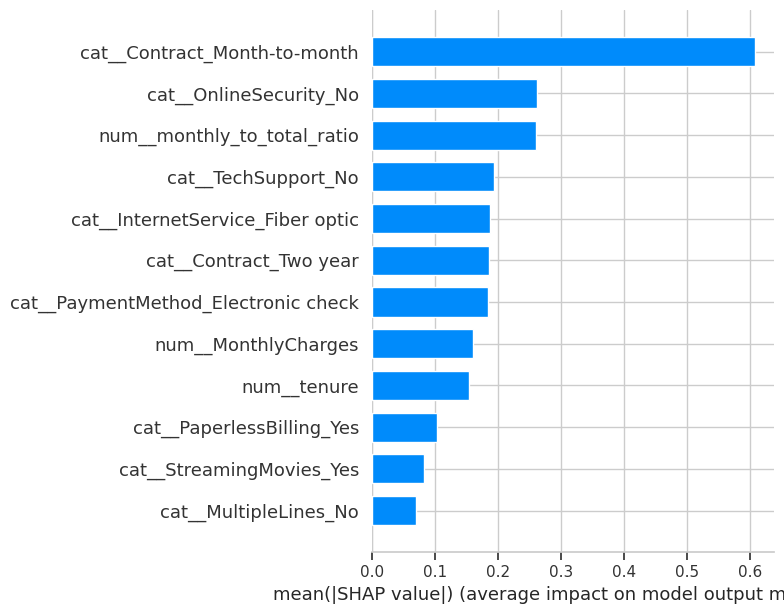

In [12]:
import shap
prep = fitted["LightGBM"].named_steps["prep"]   # TR: agac modeli SHAP icin / EN: tree model for SHAP
clf = fitted["LightGBM"].named_steps["clf"]
X_test_enc = prep.transform(X_test)
sv = shap.TreeExplainer(clf).shap_values(X_test_enc)
if isinstance(sv, list): sv = sv[1]
shap.summary_plot(sv, X_test_enc, feature_names=prep.get_feature_names_out(),
                  plot_type="bar", max_display=12)

**TR —** En güçlü churn sürücüleri: aydan aya sözleşme, düşük tenure, yüksek aylık ücret,
online güvenlik/tech support yokluğu, fiber internet ve elektronik çek ödemesi. Bunlar hem
EDA'mla hem de sezgiyle örtüşüyor.
**EN —** The strongest churn drivers: month-to-month contract, low tenure, high monthly
charges, lacking online security/tech support, fiber internet and electronic-check payment.
These match both my EDA and domain intuition.

## 8. İş önerileri & öğrendiklerim / Business recommendations & takeaways

**TR**
| Bulgu | Aksiyon |
|---|---|
| Aydan aya churn ~%43 | 1-2 yıllık sözleşmeye geçişi indirimle teşvik et |
| Churn ilk aylarda zirve | Onboarding programı + yeni müşteriye erken temas |
| Güvenlik/tech support yoksa churn artıyor | Bu servisleri paketle veya ücretsiz dene |
| Elektronik çek kullananlar daha çok churn | Otomatik ödemeye yönlendir |

**EN**
| Finding | Action |
|---|---|
| Month-to-month churn ~43% | Incentivise 1-2 year contracts with a discount |
| Churn peaks in first months | Onboarding programme + early check-ins |
| Missing security/tech support -> more churn | Bundle or free-trial these services |
| Electronic-check users churn more | Nudge toward automatic payments |

---
**TR — Bu projeden çıkardıklarım:** Doğru metriği seçmenin (accuracy değil ROC-AUC/recall)
her şeyden önemli olduğunu, en büyük iyileşmenin hiperparametre tuning'den geldiğini, ve her
popüler tekniğin (SMOTE, ensemble) işe yaramadığını — bazen zarar bile verdiğini — gördüm.
Bir sonraki adım olarak modeli bir FastAPI servisi + Streamlit paneli olarak yayına almayı
planlıyorum.

**EN — What I took away:** choosing the right metric (ROC-AUC/recall, not accuracy) matters
most, the biggest gain came from hyperparameter tuning, and not every popular trick (SMOTE,
ensembling) helps — some even hurt. As a next step I plan to deploy the model as a FastAPI
service + Streamlit dashboard.